In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [34]:
df = pd.read_csv("../data/online_retail_customer_churn.csv")

In [35]:
df_numeric = df.select_dtypes(include=[np.number])


In [36]:
df_numeric = df_numeric.dropna()

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

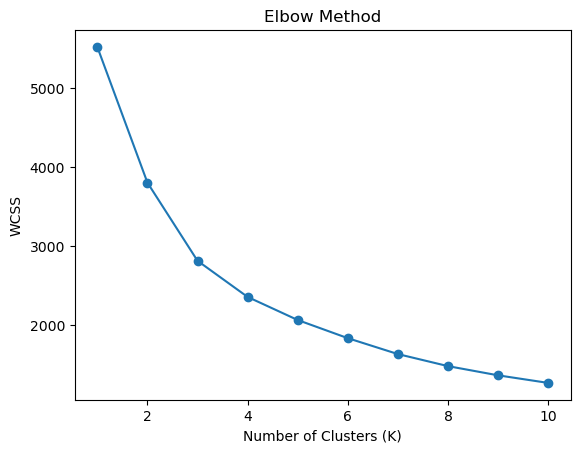

In [38]:
wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot Elbow Graph
plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

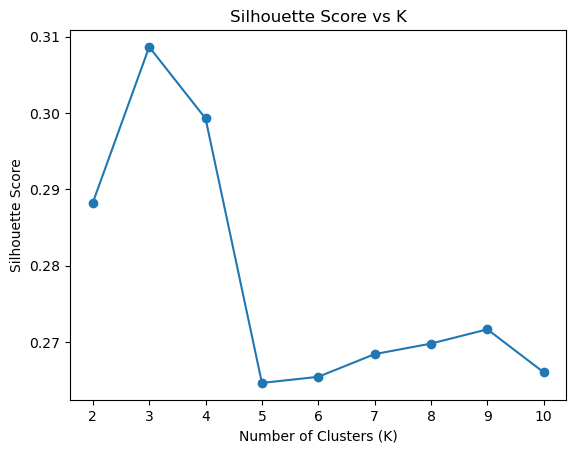

Best K according to Silhouette Score: 3


In [40]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Print best silhouette K
best_silhouette_k = np.argmax(silhouette_scores) + 2
print("Best K according to Silhouette Score:", best_silhouette_k)

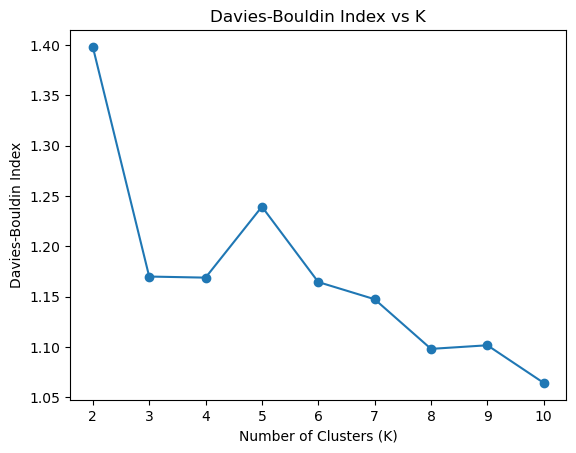

Best K according to Davies-Bouldin Index: 10


In [41]:
db_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    db_index = davies_bouldin_score(X_scaled, labels)
    db_scores.append(db_index)

# Plot DB Index
plt.figure()
plt.plot(range(2, 11), db_scores, marker='o')
plt.title("Davies-Bouldin Index vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.show()

# Print best DB K (lowest value)
best_db_k = np.argmin(db_scores) + 2
print("Best K according to Davies-Bouldin Index:", best_db_k)

In [42]:
print("\nSummary:")
print("Elbow Method: Check graph for elbow point.")
print("Silhouette Best K:", best_silhouette_k)
print("Davies-Bouldin Best K:", best_db_k)


Summary:
Elbow Method: Check graph for elbow point.
Silhouette Best K: 3
Davies-Bouldin Best K: 10


In [43]:
#Cluster Interpretation

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [44]:
df = pd.read_csv("../data/online_retail_customer_churn.csv")

In [45]:
df_original = df.copy()

In [46]:
df_numeric = df.select_dtypes(include=[np.number]).dropna()

In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

In [48]:
optimal_k = 3   # Change if needed

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [49]:
df_original['Cluster'] = clusters

In [50]:
print("\nCluster Distribution:")
print(df_original['Cluster'].value_counts())


Cluster Distribution:
Cluster
1    304
2    298
0    187
Name: count, dtype: int64


In [52]:
cluster_summary = df_original.groupby('Cluster').mean(numeric_only=True)

print("\nCluster-wise Mean Values:")
print(cluster_summary)



Cluster-wise Mean Values:
          recency  frequency     monetary  avg_spend_per_purchase  \
Cluster                                                             
0        9.823529  30.240642  6088.285348              209.820037   
1        9.417763  74.937500  7285.674803              101.503091   
2        8.741611  56.362416  2421.107349               50.231741   

         customer_value_score  recency_frequency_ratio  monetary_log  
Cluster                                                               
0               191234.666898                 0.316087      8.650072  
1               540621.480033                 0.125347      8.866888  
2               138476.703389                 0.171979      7.664423  


In [54]:
spending_columns = [col for col in df_original.columns 
                    if 'spend' in col.lower() 
                    or 'purchase' in col.lower() 
                    or 'amount' in col.lower()]

print("\nSpending Related Columns Detected:", spending_columns)

if spending_columns:
    print("\nSpending Pattern by Cluster:")
    print(df_original.groupby('Cluster')[spending_columns].mean())


Spending Related Columns Detected: ['avg_spend_per_purchase']

Spending Pattern by Cluster:
         avg_spend_per_purchase
Cluster                        
0                    209.820037
1                    101.503091
2                     50.231741


In [55]:
frequency_columns = [col for col in df_original.columns 
                     if 'frequency' in col.lower() 
                     or 'visit' in col.lower()
                     or 'transaction' in col.lower()]

print("\nFrequency Related Columns Detected:", frequency_columns)

if frequency_columns:
    print("\nFrequency Pattern by Cluster:")
    print(df_original.groupby('Cluster')[frequency_columns].mean())



Frequency Related Columns Detected: ['frequency', 'recency_frequency_ratio']

Frequency Pattern by Cluster:
         frequency  recency_frequency_ratio
Cluster                                    
0        30.240642                 0.316087
1        74.937500                 0.125347
2        56.362416                 0.171979


In [56]:
demographic_columns = df_original.select_dtypes(include=['object']).columns

for col in demographic_columns:
    print(f"\nDemographic Distribution for {col}:")
    print(pd.crosstab(df_original['Cluster'], df_original[col]))

In [57]:
if 'churn' in df_original.columns.str.lower().tolist():
    churn_column = df_original.columns[df_original.columns.str.lower() == 'churn'][0]
    print("\nChurn Rate by Cluster:")
    print(df_original.groupby('Cluster')[churn_column].mean())


In [58]:
print("\n=== Cluster Interpretation Guide ===")

for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Summary:")
    print(cluster_summary.loc[cluster])


=== Cluster Interpretation Guide ===

Cluster 0 Summary:
recency                         9.823529
frequency                      30.240642
monetary                     6088.285348
avg_spend_per_purchase        209.820037
customer_value_score       191234.666898
recency_frequency_ratio         0.316087
monetary_log                    8.650072
Name: 0, dtype: float64

Cluster 1 Summary:
recency                         9.417763
frequency                      74.937500
monetary                     7285.674803
avg_spend_per_purchase        101.503091
customer_value_score       540621.480033
recency_frequency_ratio         0.125347
monetary_log                    8.866888
Name: 1, dtype: float64

Cluster 2 Summary:
recency                         8.741611
frequency                      56.362416
monetary                     2421.107349
avg_spend_per_purchase         50.231741
customer_value_score       138476.703389
recency_frequency_ratio         0.171979
monetary_log                    7.